In [1]:
import os
import json
import warnings
warnings.filterwarnings('ignore')


In [2]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta



In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
from prophet import Prophet
import joblib
import pickle

In [5]:
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', '{:,.2f}'.format)

BRAND_PALETTE = ['#0A2647', '#1E5F8C', '#2E86AB', '#F5A623', '#F0932B', '#6AB187', '#EB5757', '#A8A8A8']
sns.set_palette(BRAND_PALETTE)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.facecolor'] = '#F8F9FA'
plt.rcParams['figure.facecolor'] = 'white'



In [6]:

df_raw = pd.read_csv( 'BrandDummy_Data.csv', low_memory=False)

print(f' Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'   Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print()
df_raw.head(5)

 Dataset loaded: 141,256 rows × 18 columns
   Memory usage: 114.8 MB



,BOOKED_DATE,ProjectRef,OM_SERVICE_TYPE,ORDERED_DATE,DESCRIPTION,QUANTITY,Value,Gross_Value,TRX_DATE,OPP_NUM_YN,ORDER_STATUS,ORDER_TYPE,ORDER_TYPE_DESC,HIRE_DURATION,ORDER_NUMBER,OM_MARKET_TYPE,PLANNED_RETURN_DATE,MARKET
0,22/Apr/2024,1100908,03 Concrete Construction,22/Apr/2024,MANTO TIE NUT,66.00,0.98,64.45,30/Apr/2024,Y,BOOKED,HIRE,AE DXB HIRE Order,150.00,"21,026,066.00",21 Residential (Multi-Family) - Commercial,5/31/2026 12:00:00 AM,21-03
1,22/Apr/2024,1100908,03 Concrete Construction,22/Apr/2024,PROTECTO multiple clamp,316.00,0.81,257.02,30/Apr/2024,Y,BOOKED,HIRE,AE DXB HIRE Order,150.00,"21,026,066.00",21 Residential (Multi-Family) - Commercial,5/31/2026 12:00:00 AM,21-03
2,22/Apr/2024,1100908,03 Concrete Construction,22/Apr/2024,PROTECTO Railing Post,447.00,0.60,267.57,30/Apr/2024,Y,BOOKED,HIRE,AE DXB HIRE Order,150.00,"21,026,066.00",21 Residential (Multi-Family) - Commercial,5/31/2026 12:00:00 AM,21-03
3,22/Apr/2024,1100908,03 Concrete Construction,22/Apr/2024,PROTECTO screw base w/o screw,15.00,0.42,6.37,30/Apr/2024,Y,BOOKED,HIRE,AE DXB HIRE Order,150.00,"21,026,066.00",21 Residential (Multi-Family) - Commercial,5/31/2026 12:00:00 AM,21-03
4,22/Apr/2024,1100908,03 Concrete Construction,22/Apr/2024,PROTECTO TOE BOARD RETAINER,174.00,0.98,169.72,30/Apr/2024,Y,BOOKED,HIRE,AE DXB HIRE Order,150.00,"21,026,066.00",21 Residential (Multi-Family) - Commercial,5/31/2026 12:00:00 AM,21-03


In [7]:
summary = pd.DataFrame({
    'dtype': df_raw.dtypes,
    'null_count': df_raw.isnull().sum(),
    'null_pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'unique_vals': df_raw.nunique(),
    'sample_value': df_raw.iloc[0]
})
print(summary.to_string())

                       dtype  null_count  null_pct  unique_vals                                sample_value
BOOKED_DATE           object           1      0.00          567                                 22/Apr/2024
ProjectRef            object           2      0.00          648                                     1100908
OM_SERVICE_TYPE       object           2      0.00            5                    03 Concrete Construction
ORDERED_DATE          object           2      0.00          564                                 22/Apr/2024
DESCRIPTION           object           2      0.00         1081                               MANTO TIE NUT
QUANTITY             float64           2      0.00          564                                       66.00
Value                float64           2      0.00        75790                                        0.98
Gross_Value          float64           2      0.00        14721                                       64.45
TRX_DATE              object

In [8]:
for col in ['ORDER_STATUS', 'ORDER_TYPE', 'OM_SERVICE_TYPE']:
    print(f'\n--- {col} ---')
    print(df_raw[col].value_counts().head(10))


--- ORDER_STATUS ---
ORDER_STATUS
CLOSED    131168
BOOKED     10086
Name: count, dtype: int64

--- ORDER_TYPE ---
ORDER_TYPE
HIRE    134021
SALE      5025
OEA       2208
Name: count, dtype: int64

--- OM_SERVICE_TYPE ---
OM_SERVICE_TYPE
03 Concrete Construction     141158
32 ISS Specialty Services        38
00 NoServiceType                 35
01 Commercial Scaffolding        15
21 Heat Tracing                   8
Name: count, dtype: int64


In [9]:
df = df_raw.copy()


In [10]:
for col in ['BOOKED_DATE', 'ORDERED_DATE', 'TRX_DATE']:
    df[col] = pd.to_datetime(df[col], format='%d/%b/%Y', errors='coerce')

In [11]:
# Parse PLANNED_RETURN_DATE — mixed AM/PM US format
# '5/31/2026 12:00:00 AM' → We only need the date part
# -------------------------------------------------------
df['PLANNED_RETURN_DATE'] = pd.to_datetime(
    df['PLANNED_RETURN_DATE'],
    format='%m/%d/%Y %I:%M:%S %p',
    errors='coerce'
)

# Report parse success rates
for col in ['BOOKED_DATE', 'ORDERED_DATE', 'TRX_DATE', 'PLANNED_RETURN_DATE']:
    null_count = df[col].isnull().sum()
    success_pct = (1 - null_count / len(df)) * 100
    print(f'  {col:25s}: {success_pct:.1f}% parsed ({null_count:,} nulls)')

# Drop rows where critical dates failed to parse
initial_len = len(df)
df = df.dropna(subset=['TRX_DATE'])
print(f'\n  Dropped {initial_len - len(df):,} rows with unparseable TRX_DATE.')
print(f'  Remaining rows: {len(df):,}')

  BOOKED_DATE              : 100.0% parsed (2 nulls)
  ORDERED_DATE             : 100.0% parsed (2 nulls)
  TRX_DATE                 : 100.0% parsed (2 nulls)
  PLANNED_RETURN_DATE      : 93.1% parsed (9,811 nulls)

  Dropped 2 rows with unparseable TRX_DATE.
  Remaining rows: 141,254


In [12]:
print(df['QUANTITY'].describe())
print(f'\nNegative QUANTITY rows: {(df["QUANTITY"] < 0).sum():,}')
print(f'Zero QUANTITY rows:     {(df["QUANTITY"] == 0).sum():,}')


count   141,254.00
mean         41.81
std          88.40
min        -900.00
25%           4.00
50%          10.00
75%          40.00
max       3,820.00
Name: QUANTITY, dtype: float64

Negative QUANTITY rows: 540
Zero QUANTITY rows:     28


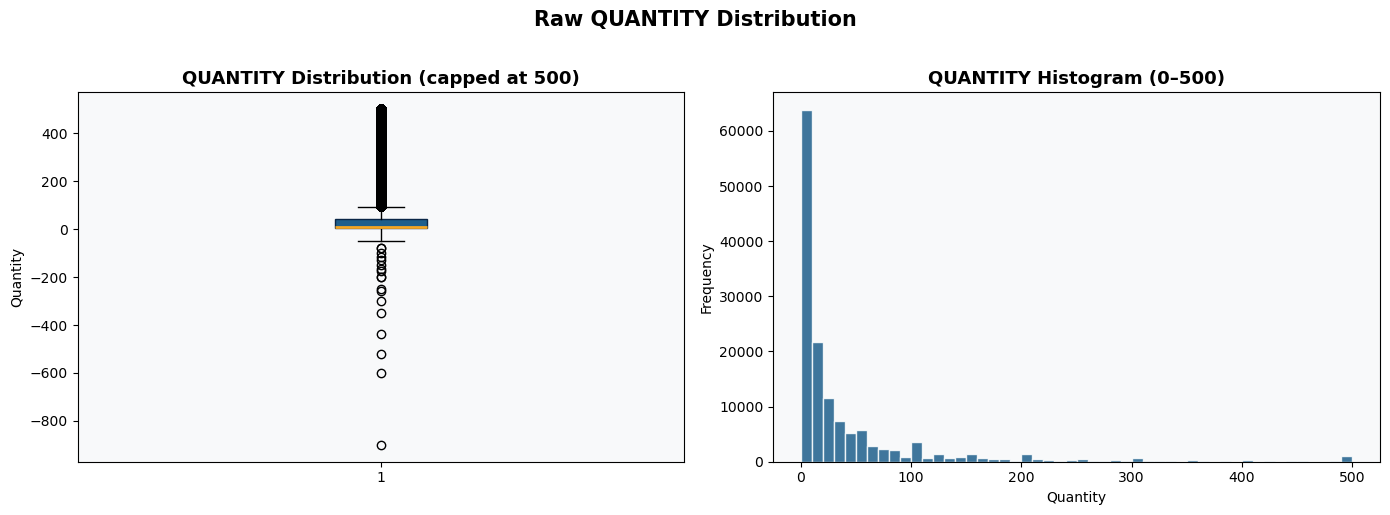

📊 Plot saved to plots/quantity_distribution.png


In [13]:
# Visualise distribution before cleaning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
axes[0].boxplot(df['QUANTITY'].clip(upper=500), patch_artist=True,
                boxprops=dict(facecolor='#1E5F8C', color='#0A2647'),
                medianprops=dict(color='#F5A623', linewidth=2))
axes[0].set_title('QUANTITY Distribution (capped at 500)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Quantity')

# Histogram
axes[1].hist(df['QUANTITY'].clip(0, 500), bins=50, color='#1E5F8C', edgecolor='white', alpha=0.85)
axes[1].set_title('QUANTITY Histogram (0–500)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('Frequency')

plt.suptitle('Raw QUANTITY Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/quantity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Plot saved to plots/quantity_distribution.png')

The company experiences a large number of small equipment hire requests and a relatively small number of high-volume orders. These large projects have a significant impact on overall demand and inventory planning. Proper handling of these extreme values is essential to ensure that the forecasting model accurately predicts future demand without being biased by a few unusually large transactions.

In [14]:
os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)
# Filter for outgoing HIRE orders only
# We exclude negative quantities (returns/credits) and
# zero quantities (placeholders)

df = df[df['QUANTITY'] > 0].copy()
df = df[df['ORDER_TYPE'] == 'HIRE'].copy()


# IQR Outlier Capping (Winsorization)
# Rather than REMOVING outliers which loses information,
# we CAP them at the fence values. This technique is called
# Winsorization and is preferred in forecasting contexts.

Q1 = df['QUANTITY'].quantile(0.25)
Q3 = df['QUANTITY'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 3.0 * IQR  # Using 3× IQR (more lenient) — bulk orders ARE real demand

outlier_count = (df['QUANTITY'] > upper_fence).sum()
df['QUANTITY'] = df['QUANTITY'].clip(upper=upper_fence)

print(f'IQR Outlier Analysis:')
print(f'  Q1={Q1:.0f}, Q3={Q3:.0f}, IQR={IQR:.0f}')
print(f'  Upper fence (3×IQR): {upper_fence:.0f}')
print(f'  Rows capped: {outlier_count:,} ({outlier_count/len(df)*100:.1f}%)')
print(f'\nPost-cleaning dataset: {len(df):,} rows')

IQR Outlier Analysis:
  Q1=4, Q3=40, IQR=36
  Upper fence (3×IQR): 148
  Rows capped: 10,140 (7.6%)

Post-cleaning dataset: 133,668 rows


In [15]:

# Rule-Based Equipment Category Classification
# Uses case-insensitive substring matching


CATEGORY_RULES = {
    'Formwork Panels': [
        'panel', 'manto-panel', 'manto panel', 'rasto-panel', 'rasto panel',
        'takko-panel', 'takko panel', 'giant panel', 'protecto panel',
        'inner corner', 'outer corner', 'corner adjust', 'corner clamp'
    ],
    'Accessories & Connectors': [
        'clamp', 'tie nut', 'bolt', 'connector', 'wedge', 'pin', 'hook',
        'fastener', 'nut', 'screw', 'element connector', 'panel clamp',
        'fork head', 'bulkhead'
    ],
    'Alignment & Struts': [
        'aligning strut', 'alignment strut', 'strut', 'm-aligning',
        'strut head', 'strut connector', 'push pull', 'prop', 'adaptor for alignment'
    ],
    'Safety & Railings': [
        'railing', 'toe board', 'safety', 'protecto railing',
        'guard', 'barrier', 'handrail'
    ],
    'Transport & Storage': [
        'lattice box', 'stacking frame', 'transport hook', 'loading adapter',
        'crane adaptor', 'euro lattice', 'euro stacking', 'pallet'
    ],
    'Scaffolding Components': [
        'scaffold', 'ledger', 'transom', 'standard', 'coupler',
        'spigot', 'base plate', 'u-head', 'jack'
    ],
    'Walers & Beams': [
        'waler', 'waling', 'beam', 'wailer', 'multi purpose waler'
    ]
}

def classify_equipment(description: str) -> str:
    """Map a raw equipment description to one of 8 categories."""
    if not isinstance(description, str):
        return 'Other'
    desc_lower = description.lower()
    for category, keywords in CATEGORY_RULES.items():
        if any(kw in desc_lower for kw in keywords):
            return category
    return 'Other'

df['EQUIPMENT_CATEGORY'] = df['DESCRIPTION'].apply(classify_equipment)

# Report classification results
category_dist = df.groupby('EQUIPMENT_CATEGORY')['QUANTITY'].sum().sort_values(ascending=False)
total_qty = category_dist.sum()
print('Equipment Category Distribution (by total QUANTITY hired):')
print('=' * 60)
for cat, qty in category_dist.items():
    bar = '█' * int(qty / total_qty * 40)
    print(f'  {cat:30s}: {qty:>10,.0f}  ({qty/total_qty*100:4.1f}%)  {bar}')

Equipment Category Distribution (by total QUANTITY hired):
  Accessories & Connectors      :  1,250,614  (29.0%)  ███████████
  Other                         :  1,137,648  (26.3%)  ██████████
  Alignment & Struts            :    558,077  (12.9%)  █████
  Walers & Beams                :    512,576  (11.9%)  ████
  Formwork Panels               :    508,904  (11.8%)  ████
  Safety & Railings             :    152,653  ( 3.5%)  █
  Scaffolding Components        :    133,104  ( 3.1%)  █
  Transport & Storage           :     64,975  ( 1.5%)  


In [16]:
#Temporal Feature Engineering from TRX_DATE
df['year']         = df['TRX_DATE'].dt.year
df['month']        = df['TRX_DATE'].dt.month
df['quarter']      = df['TRX_DATE'].dt.quarter
df['week_of_year'] = df['TRX_DATE'].dt.isocalendar().week.astype(int)
df['day_of_week']  = df['TRX_DATE'].dt.dayofweek   # 0=Monday, 6=Sunday
df['day_of_month'] = df['TRX_DATE'].dt.day
df['is_month_end'] = df['TRX_DATE'].dt.is_month_end.astype(int)
df['is_quarter_end'] = df['TRX_DATE'].dt.is_quarter_end.astype(int)

# Encode season (UAE context: Winter=cooler construction peak, Summer=slowdown)
def get_season(month: int) -> str:
    if month in [12, 1, 2]:   return 'Winter'
    elif month in [3, 4, 5]:  return 'Spring'
    elif month in [6, 7, 8]:  return 'Summer'
    else:                      return 'Autumn'

df['season'] = df['month'].apply(get_season)


In [17]:
# Hire Duration Category
# Binning continuous HIRE_DURATION into meaningful buckets
df['hire_duration_cat'] = pd.cut(
    df['HIRE_DURATION'],
    bins=[0, 30, 90, 180, 365, np.inf],
    labels=['Short (<30d)', 'Medium (30-90d)', 'Long (90-180d)', 'Extended (180-365d)', 'Multi-Year']
)


In [18]:
# Planned Return Horizon (days from booking to return)
df['return_horizon_days'] = (df['PLANNED_RETURN_DATE'] - df['BOOKED_DATE']).dt.days
df['return_horizon_days'] = df['return_horizon_days'].clip(lower=0)  # Remove negative (data errors)

In [19]:
#days from booking to transaction
df['lead_time_days'] = (df['TRX_DATE'] - df['BOOKED_DATE']).dt.days
df['lead_time_days'] = df['lead_time_days'].clip(lower=0)

In [20]:
print(' Temporal features engineered.')
print(f'   New columns added: year, month, quarter, week_of_year, day_of_week,')
print(f'   day_of_month, is_month_end, is_quarter_end, season,')
print(f'   hire_duration_cat, return_horizon_days, lead_time_days')
print(f'\n   Dataset shape: {df.shape}')

 Temporal features engineered.
   New columns added: year, month, quarter, week_of_year, day_of_week,
   day_of_month, is_month_end, is_quarter_end, season,
   hire_duration_cat, return_horizon_days, lead_time_days

   Dataset shape: (133668, 31)


Create Weekly Time Series Aggregations

In [22]:
# Weekly Demand Series
# Aggregate total QUANTITY by week and EQUIPMENT_CATEGORY
df['trx_week'] = df['TRX_DATE'].dt.to_period('W').dt.start_time

weekly_demand = (
    df.groupby(['trx_week', 'EQUIPMENT_CATEGORY'])['QUANTITY']
    .sum()
    .reset_index()
    .rename(columns={'trx_week': 'week', 'QUANTITY': 'total_qty'})
)

# Total demand (all categories combined)
weekly_demand_total = (
    df.groupby('trx_week')['QUANTITY']
    .sum()
    .reset_index()
    .rename(columns={'trx_week': 'week', 'QUANTITY': 'total_qty'})
)
weekly_demand_total = weekly_demand_total.sort_values('week').reset_index(drop=True)

In [23]:
# Weekly Return Series
# Aggregate expected returns by PLANNED_RETURN_DATE week
df_with_return = df.dropna(subset=['PLANNED_RETURN_DATE']).copy()
df_with_return['return_week'] = df_with_return['PLANNED_RETURN_DATE'].dt.to_period('W').dt.start_time

weekly_returns = (
    df_with_return.groupby('return_week')['QUANTITY']
    .sum()
    .reset_index()
    .rename(columns={'return_week': 'week', 'QUANTITY': 'expected_returns'})
)
weekly_returns = weekly_returns.sort_values('week').reset_index(drop=True)

In [24]:
print('Weekly Demand Series shape:', weekly_demand_total.shape)
print(f'Date range: {weekly_demand_total["week"].min().date()} → {weekly_demand_total["week"].max().date()}')
print(f'\nWeekly Returns Series shape: {weekly_returns.shape}')
print(weekly_demand_total.tail(5))

Weekly Demand Series shape: (101, 2)
Date range: 2023-01-09 → 2024-12-30

Weekly Returns Series shape: (66, 2)
          week  total_qty
96  2024-11-25 222,200.00
97  2024-12-02      24.00
98  2024-12-09      27.00
99  2024-12-16      49.00
100 2024-12-30 208,849.00


EDA

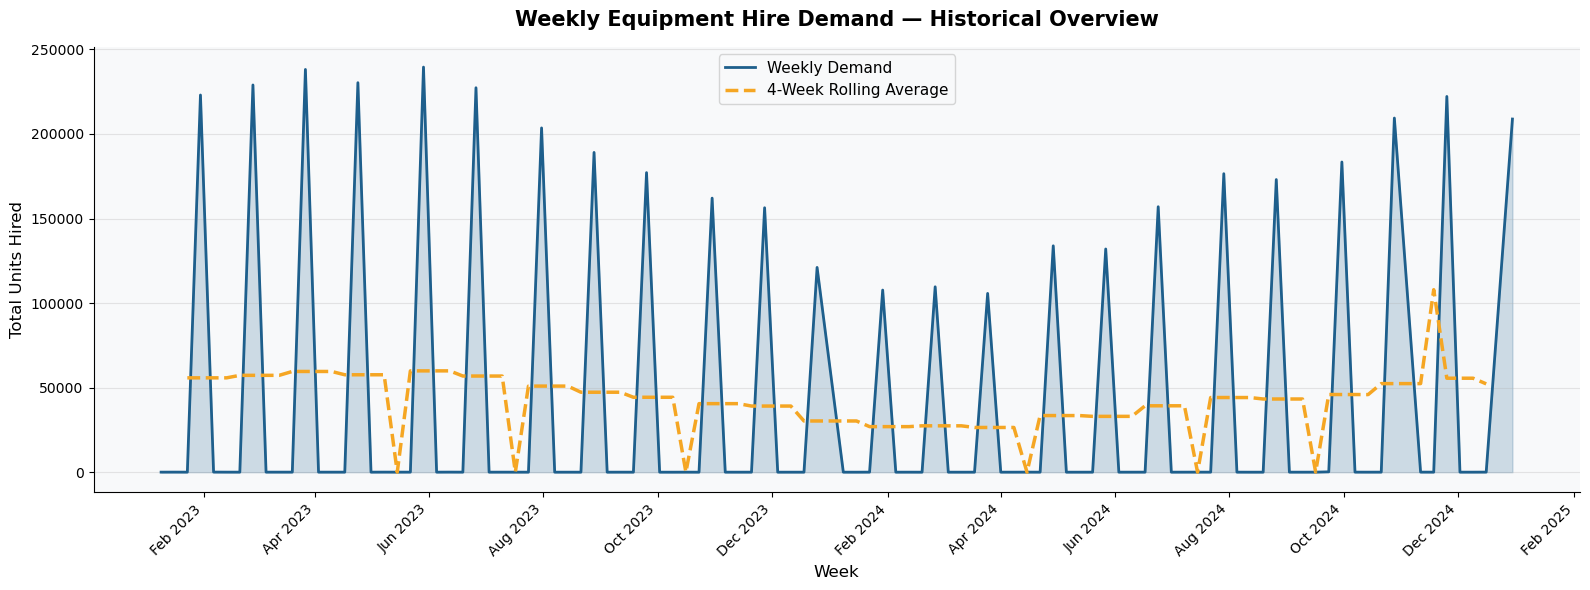

 Saved: plots/total_weekly_demand.png

 OBSERVATION: Look for repeating peaks — these indicate seasonality.
   A growing trend in the rolling average suggests underlying business growth.


In [26]:
#Total Weekly Demand Over Time
fig, ax = plt.subplots(figsize=(16, 6))

ax.fill_between(weekly_demand_total['week'], weekly_demand_total['total_qty'],
                alpha=0.2, color='#1E5F8C')
ax.plot(weekly_demand_total['week'], weekly_demand_total['total_qty'],
        color='#1E5F8C', linewidth=2, label='Weekly Demand')

# Add 4-week rolling average
rolling_avg = weekly_demand_total['total_qty'].rolling(4, center=True).mean()
ax.plot(weekly_demand_total['week'], rolling_avg,
        color='#F5A623', linewidth=2.5, linestyle='--', label='4-Week Rolling Average')

ax.set_title('Weekly Equipment Hire Demand — Historical Overview',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Week', fontsize=12)
ax.set_ylabel('Total Units Hired', fontsize=12)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plots/total_weekly_demand.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: plots/total_weekly_demand.png')
print('\n OBSERVATION: Look for repeating peaks — these indicate seasonality.')
print('   A growing trend in the rolling average suggests underlying business growth.')

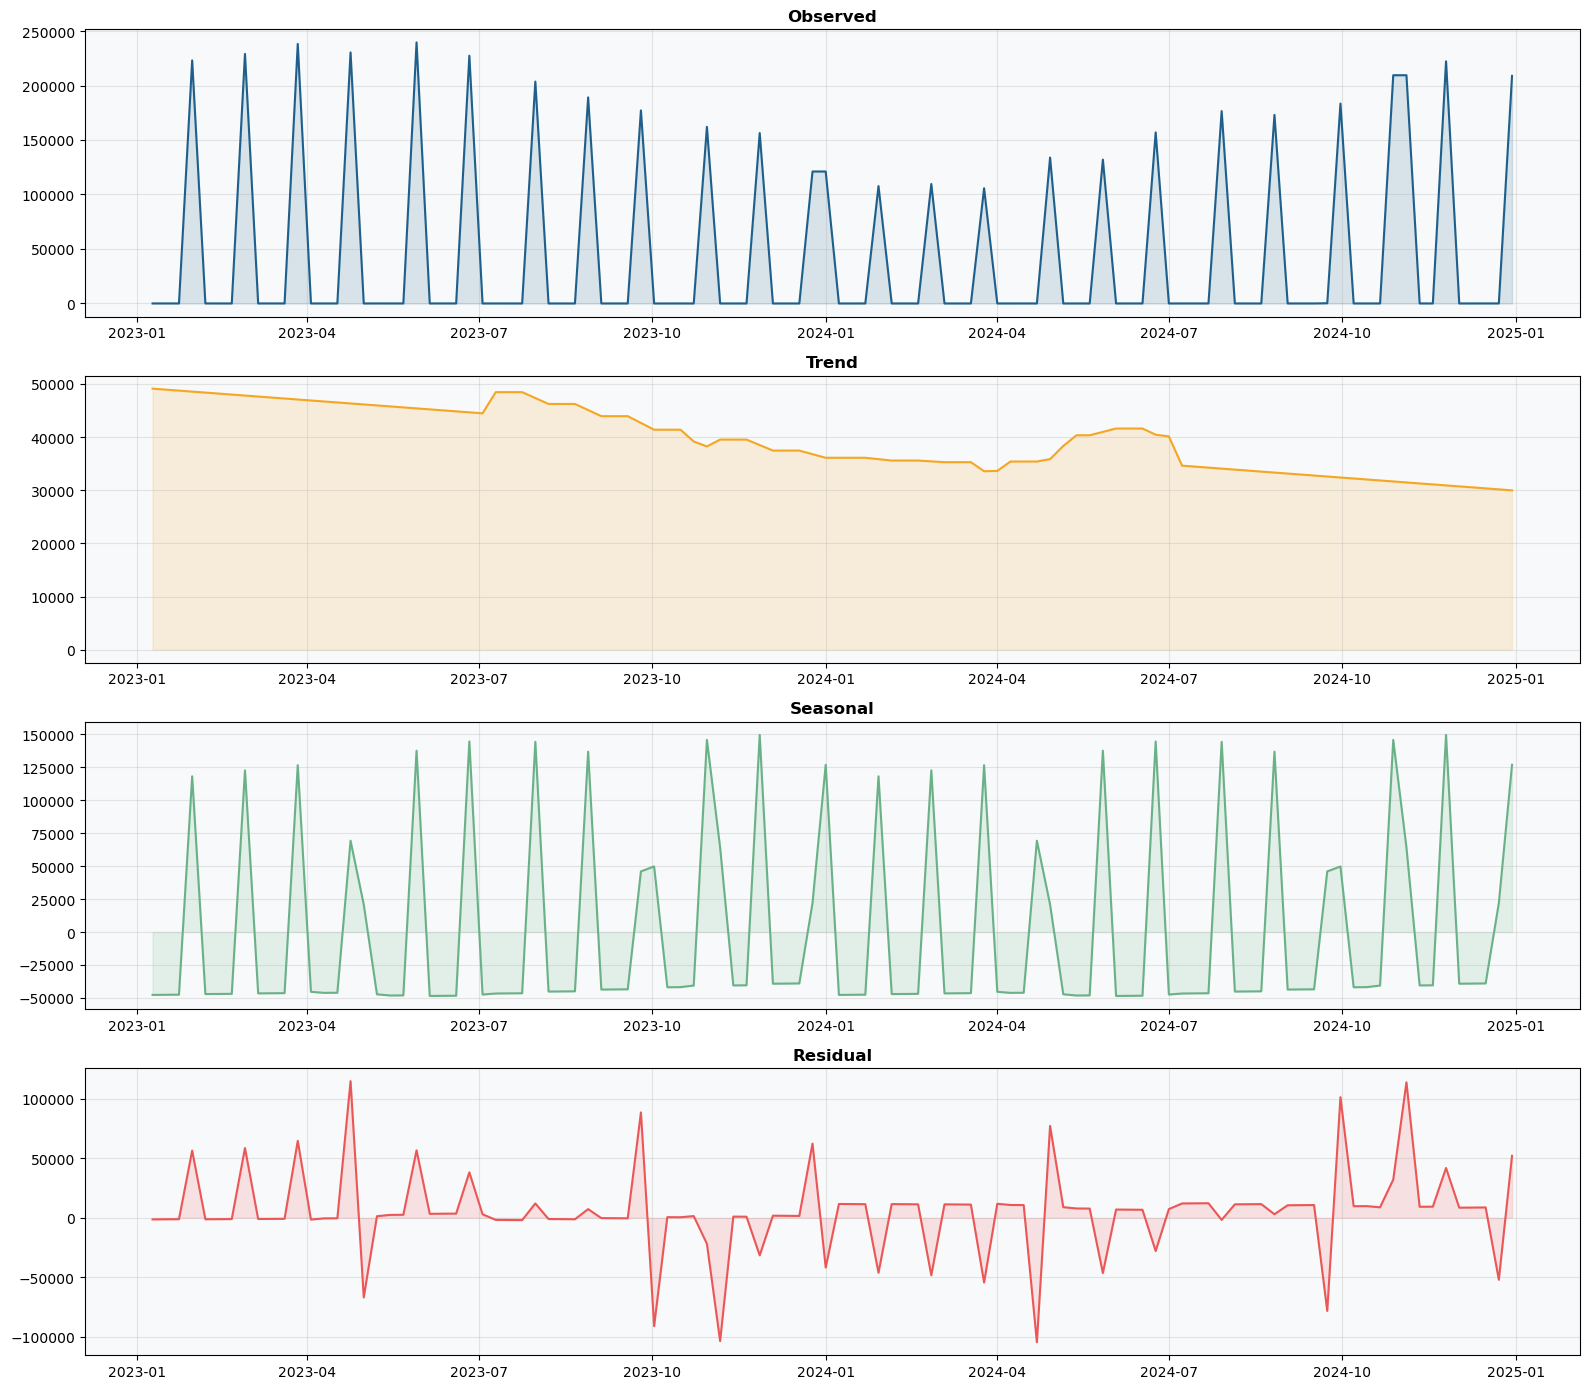

In [27]:

# EDA CHART 2: Seasonal Decomposition

# Create time series
ts_demand = weekly_demand_total.set_index('week')['total_qty']

# Convert index to datetime
ts_demand.index = pd.to_datetime(ts_demand.index)

# Sort by date
ts_demand = ts_demand.sort_index()

# Create a complete weekly index
full_index = pd.date_range(
    start=ts_demand.index.min(),
    end=ts_demand.index.max(),
    freq='W-MON'
)

# Reindex and fill missing weeks
ts_demand = ts_demand.reindex(full_index)
ts_demand = ts_demand.ffill()

# Seasonal decomposition
try:
    decomp = seasonal_decompose(
        ts_demand,
        model='additive',
        period=52,
        extrapolate_trend='freq'
    )

    fig, axes = plt.subplots(4, 1, figsize=(16,14))

    components = [
        (decomp.observed,'Observed','#1E5F8C'),
        (decomp.trend,'Trend','#F5A623'),
        (decomp.seasonal,'Seasonal','#6AB187'),
        (decomp.resid,'Residual','#EB5757')
    ]

    for ax,(data,title,color) in zip(axes,components):
        ax.plot(data,color=color,linewidth=1.5)
        ax.fill_between(data.index,data,alpha=0.15,color=color)
        ax.set_title(title,fontweight='bold')
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(e)

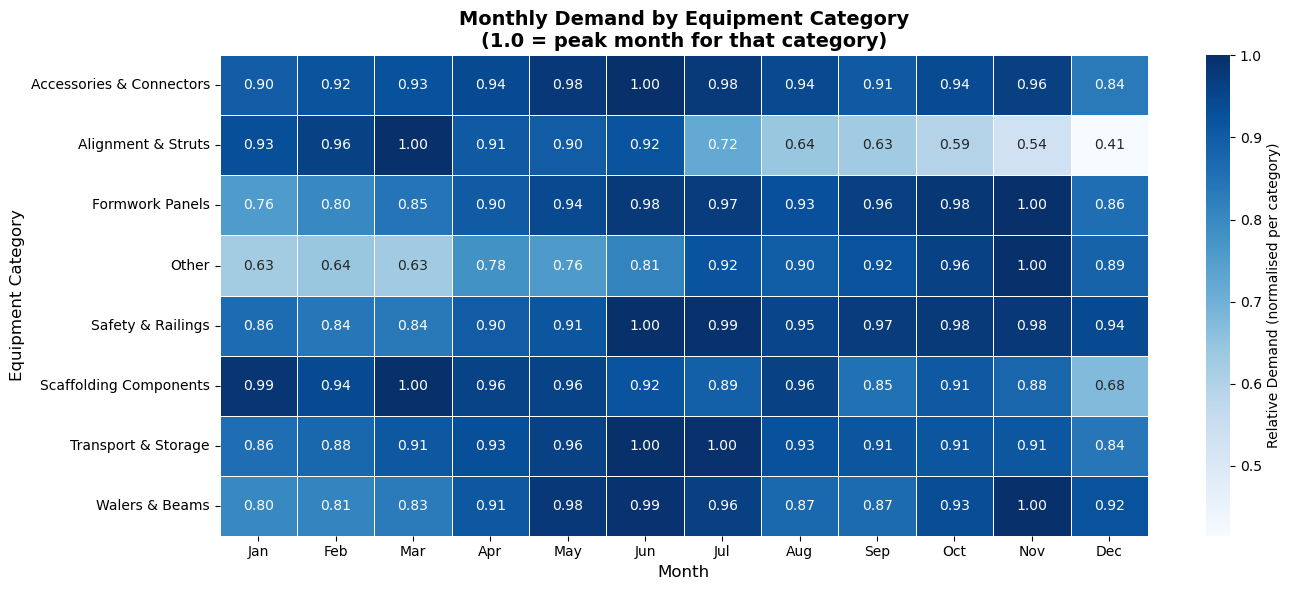

 Saved: plots/category_month_heatmap.png

 OBSERVATION: Values close to 1.0 indicate peak demand months for that category.


In [28]:

# EDA CHART 3: Demand by Month × Equipment Category (Heatmap)


# Pivot: rows=Category, columns=Month
monthly_cat = df.groupby(['EQUIPMENT_CATEGORY', 'month'])['QUANTITY'].sum().reset_index()
heatmap_data = monthly_cat.pivot(index='EQUIPMENT_CATEGORY', columns='month', values='QUANTITY').fillna(0)
heatmap_data.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Normalise each row to show RELATIVE peaks within each category
heatmap_norm = heatmap_data.div(heatmap_data.max(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    heatmap_norm,
    annot=True, fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Relative Demand (normalised per category)'}
)
ax.set_title('Monthly Demand by Equipment Category\n(1.0 = peak month for that category)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Equipment Category', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
plt.tight_layout()
plt.savefig('plots/category_month_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: plots/category_month_heatmap.png')
print('\n OBSERVATION: Values close to 1.0 indicate peak demand months for that category.')

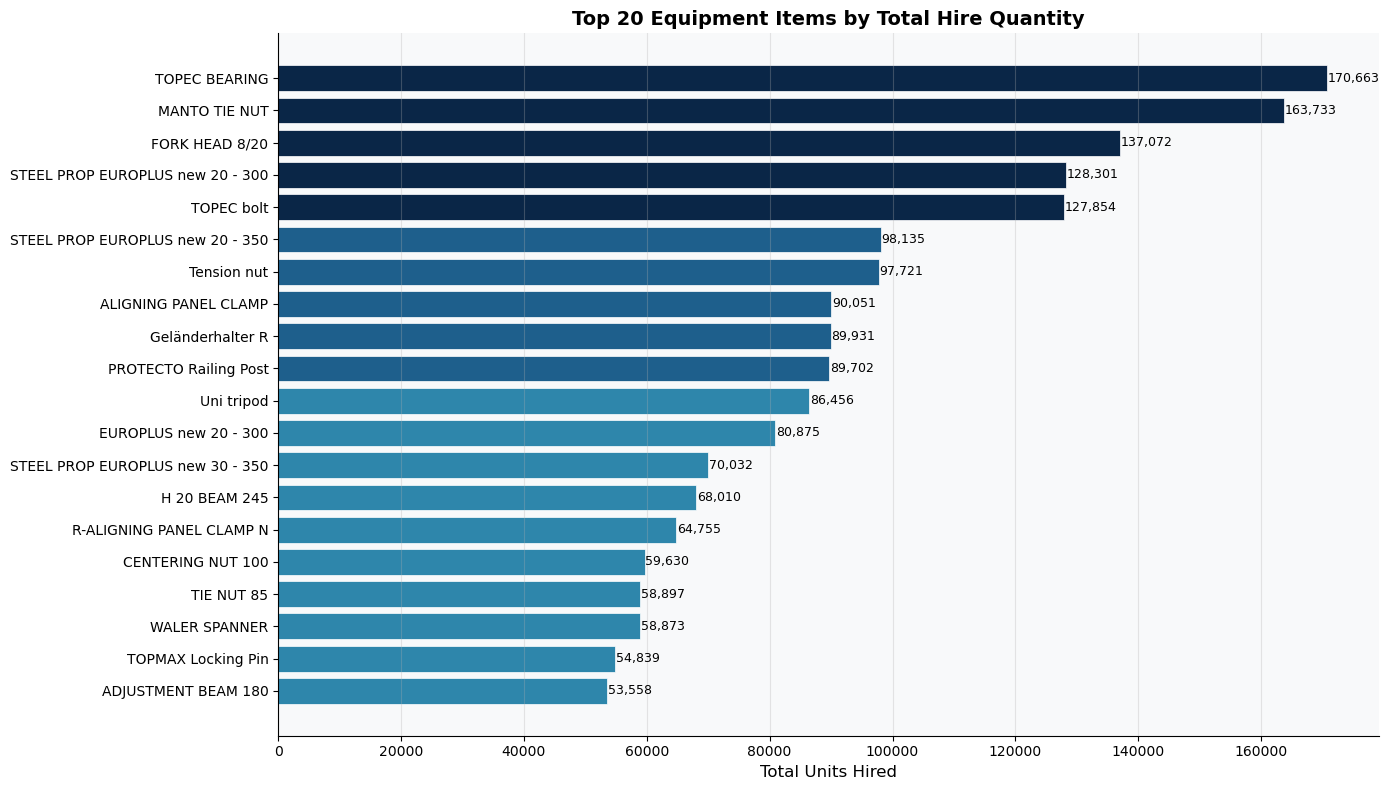

 Saved: plots/top20_equipment.png


In [29]:

# EDA CHART 4: Top 20 Equipment Items by Total Quantity


top20 = df.groupby('DESCRIPTION')['QUANTITY'].sum().nlargest(20).reset_index()
top20.columns = ['Description', 'Total Quantity']
top20['Description'] = top20['Description'].str[:45]  # Truncate long names

fig, ax = plt.subplots(figsize=(14, 8))
colors = [BRAND_PALETTE[0]] * 5 + [BRAND_PALETTE[1]] * 5 + [BRAND_PALETTE[2]] * 10
bars = ax.barh(top20['Description'][::-1], top20['Total Quantity'][::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.5)

# Add value labels
for bar, val in zip(bars, top20['Total Quantity'][::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=9)

ax.set_title('Top 20 Equipment Items by Total Hire Quantity', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Units Hired', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/top20_equipment.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: plots/top20_equipment.png')

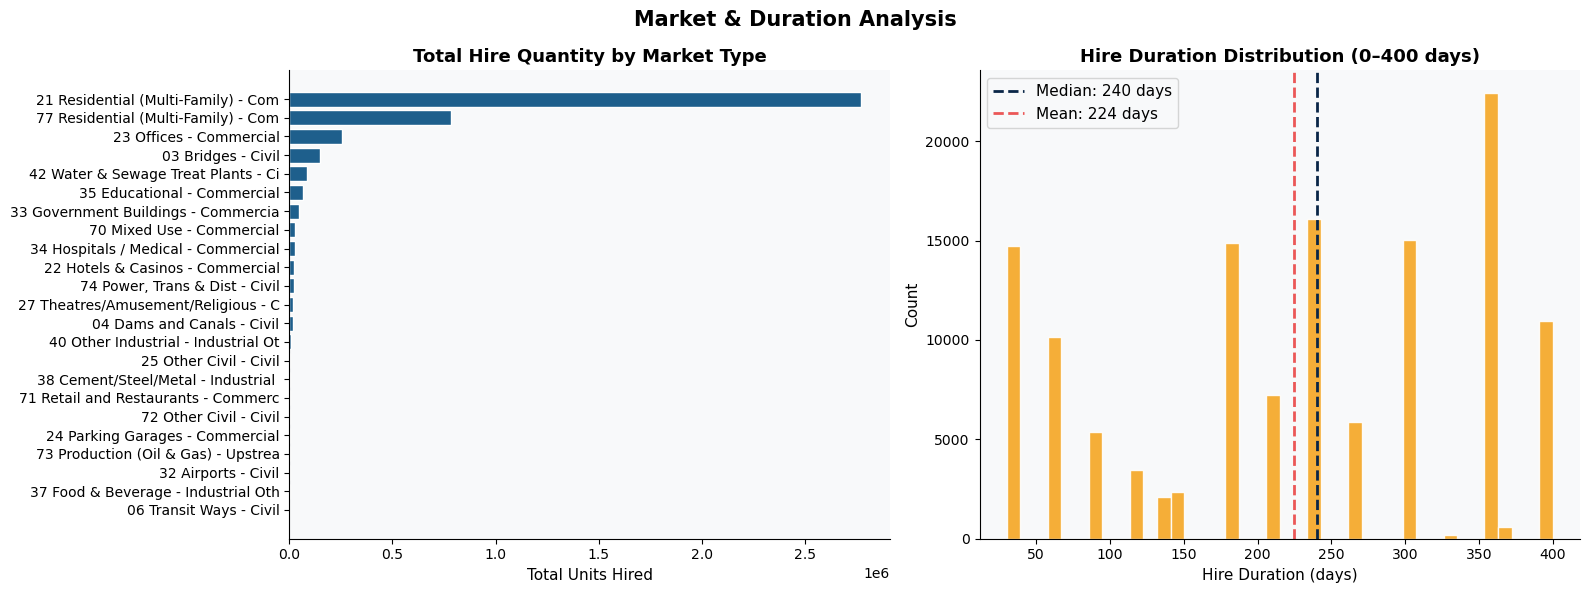

Saved: plots/market_and_duration.png

 KEY INSIGHT: The median hire duration of 240 days means equipment
   is tied up for months, making return date forecasting critical for inventory planning.


In [30]:

#  Market Distribution & Hire Duration

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 5a: Market Type Distribution
market_qty = df.groupby('OM_MARKET_TYPE')['QUANTITY'].sum().sort_values(ascending=True)
# Shorten market names for display
market_qty.index = [m[:35] for m in market_qty.index]

axes[0].barh(market_qty.index, market_qty.values,
             color='#1E5F8C', edgecolor='white')
axes[0].set_title('Total Hire Quantity by Market Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Units Hired', fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Chart 5b: Hire Duration Distribution
hire_dur = df['HIRE_DURATION'].clip(0, 400)
axes[1].hist(hire_dur, bins=40, color='#F5A623', edgecolor='white', alpha=0.9)
axes[1].axvline(hire_dur.median(), color='#0A2647', linestyle='--', linewidth=2,
                label=f'Median: {hire_dur.median():.0f} days')
axes[1].axvline(hire_dur.mean(), color='#EB5757', linestyle='--', linewidth=2,
                label=f'Mean: {hire_dur.mean():.0f} days')
axes[1].set_title('Hire Duration Distribution (0–400 days)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hire Duration (days)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].legend(fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Market & Duration Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/market_and_duration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/market_and_duration.png')
print(f'\n KEY INSIGHT: The median hire duration of {hire_dur.median():.0f} days means equipment')
print('   is tied up for months, making return date forecasting critical for inventory planning.')

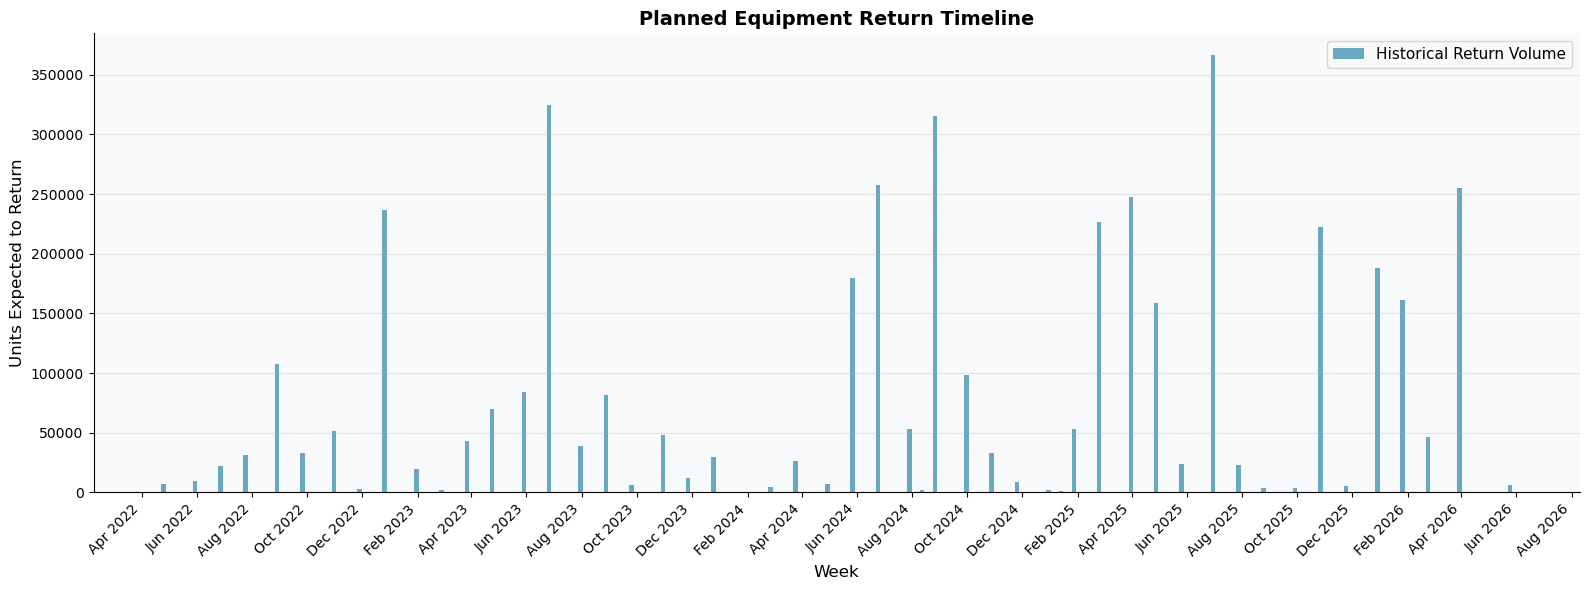

Saved: plots/return_timeline.png


In [31]:
# EDA CHART 6: Planned Return Timeline

#This chart shows when currently-active equipment is expected to be returned. This is the 'supply restoration' side of the inventory equation.

fig, ax = plt.subplots(figsize=(16, 6))

# Focus on future returns (from today's date)
today = pd.Timestamp.now()
future_returns = weekly_returns[weekly_returns['week'] >= today]
all_returns = weekly_returns.tail(52)  # Last year of return data

ax.bar(all_returns['week'], all_returns['expected_returns'],
       width=5, color='#2E86AB', alpha=0.7, label='Historical Return Volume')

if not future_returns.empty:
    ax.bar(future_returns['week'], future_returns['expected_returns'],
           width=5, color='#F5A623', label='Upcoming Returns (Forecast Window)')
    ax.axvline(today, color='#EB5757', linestyle='--', linewidth=2, label='Today')

ax.set_title('Planned Equipment Return Timeline', fontsize=14, fontweight='bold')
ax.set_xlabel('Week', fontsize=12)
ax.set_ylabel('Units Expected to Return', fontsize=12)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plots/return_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/return_timeline.png')

Forecasting Framework

=== Temporal Train/Test Split ===
  Training: 2023-01-09 → 2024-09-16  (88 weeks)
  Testing:  2024-09-23  → 2024-12-30   (13 weeks)



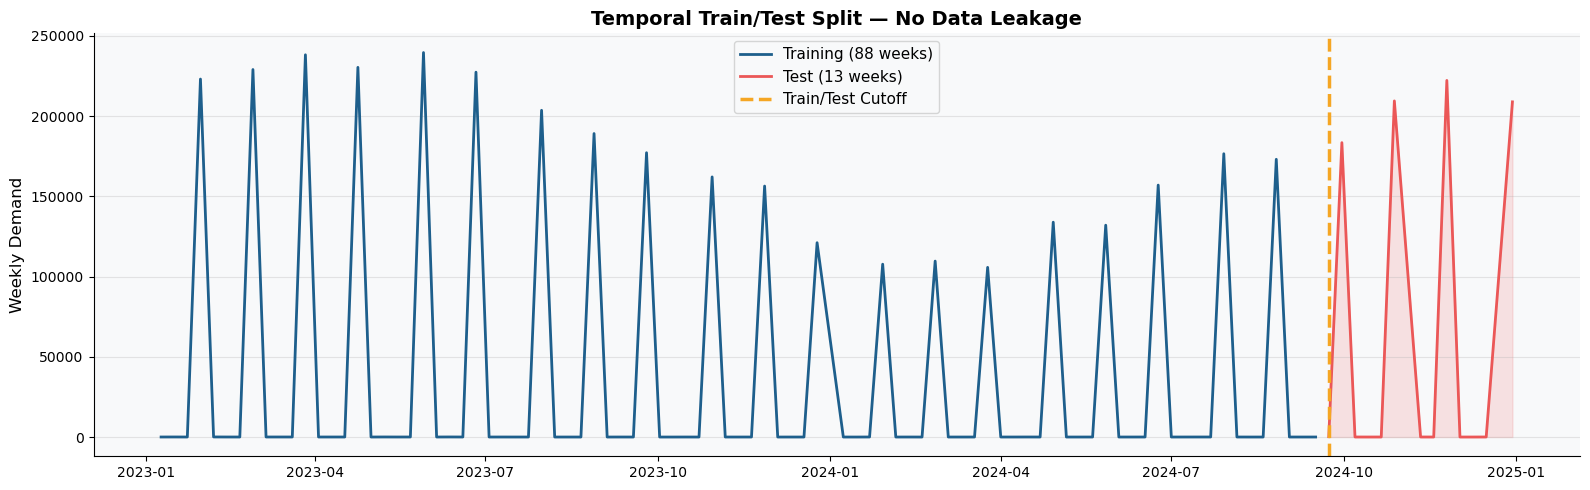

In [33]:

# Temporal Train/Test Split
# Use the last 13 weeks (3 months) as the test set
# This simulates a 90-day forecast evaluation

TEST_WEEKS = 13  # ~3 months

ts = weekly_demand_total.sort_values('week').reset_index(drop=True)

split_idx = len(ts) - TEST_WEEKS
train_ts = ts.iloc[:split_idx].copy()
test_ts  = ts.iloc[split_idx:].copy()

train_start = train_ts['week'].min().date()
train_end   = train_ts['week'].max().date()
test_start  = test_ts['week'].min().date()
test_end    = test_ts['week'].max().date()

print('=== Temporal Train/Test Split ===')
print(f'  Training: {train_start} → {train_end}  ({len(train_ts)} weeks)')
print(f'  Testing:  {test_start}  → {test_end}   ({len(test_ts)} weeks)')
print()

# Visualise the split
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train_ts['week'], train_ts['total_qty'],
        color='#1E5F8C', linewidth=2, label=f'Training ({len(train_ts)} weeks)')
ax.plot(test_ts['week'], test_ts['total_qty'],
        color='#EB5757', linewidth=2, label=f'Test ({len(test_ts)} weeks)')
ax.axvline(test_ts['week'].iloc[0], color='#F5A623', linestyle='--',
           linewidth=2.5, label='Train/Test Cutoff')
ax.fill_between(test_ts['week'], test_ts['total_qty'], alpha=0.15, color='#EB5757')
ax.set_title('Temporal Train/Test Split — No Data Leakage', fontsize=14, fontweight='bold')
ax.set_ylabel('Weekly Demand', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plots/train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# ============================================================
# Prophet Forecast
# ============================================================

# Prepare Prophet-format DataFrames
prophet_train = train_ts.rename(columns={'week': 'ds', 'total_qty': 'y'})
prophet_test  = test_ts.rename(columns={'week': 'ds', 'total_qty': 'y'})

# Ensure datetime format
prophet_train['ds'] = pd.to_datetime(prophet_train['ds'])
prophet_test['ds'] = pd.to_datetime(prophet_test['ds'])

# Create Prophet model
prophet_model = Prophet(
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.1,
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.80
)

# Train
prophet_model.fit(prophet_train)

# Forecast
future_df = prophet_model.make_future_dataframe(
    periods=TEST_WEEKS,
    freq='W-MON'          # use same weekly frequency as your data
)

prophet_forecast = prophet_model.predict(future_df)

# Keep only the test dates
prophet_test_pred = (
    prophet_forecast[
        prophet_forecast['ds'].isin(prophet_test['ds'])
    ][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
    .reset_index(drop=True)
)

# Clip ONLY numeric columns
cols = ['yhat', 'yhat_lower', 'yhat_upper']
prophet_test_pred[cols] = prophet_test_pred[cols].clip(lower=0)

print("✅ Prophet training complete!")
print(f"Training data points : {len(prophet_train)}")
print(f"Forecast data points : {len(prophet_test_pred)}")

09:57:07 - cmdstanpy - INFO - Chain [1] start processing
09:57:07 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet training complete!
Training data points : 88
Forecast data points : 12


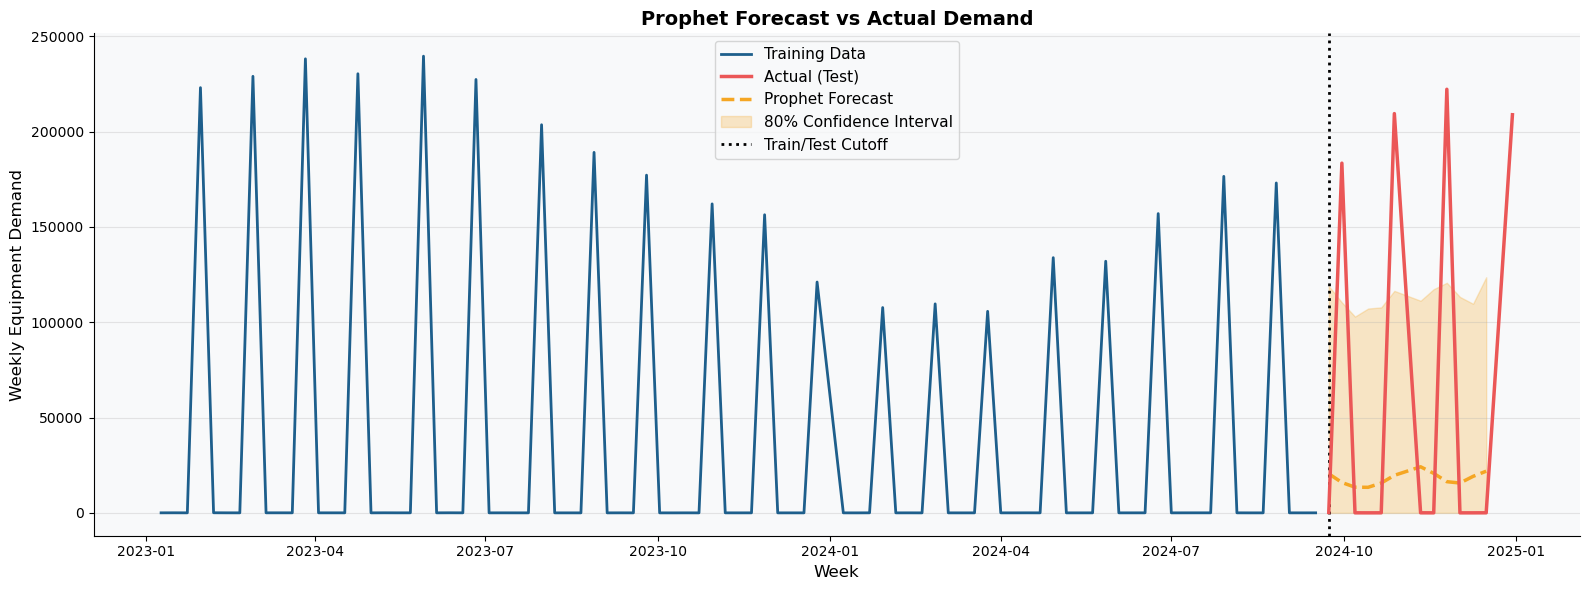

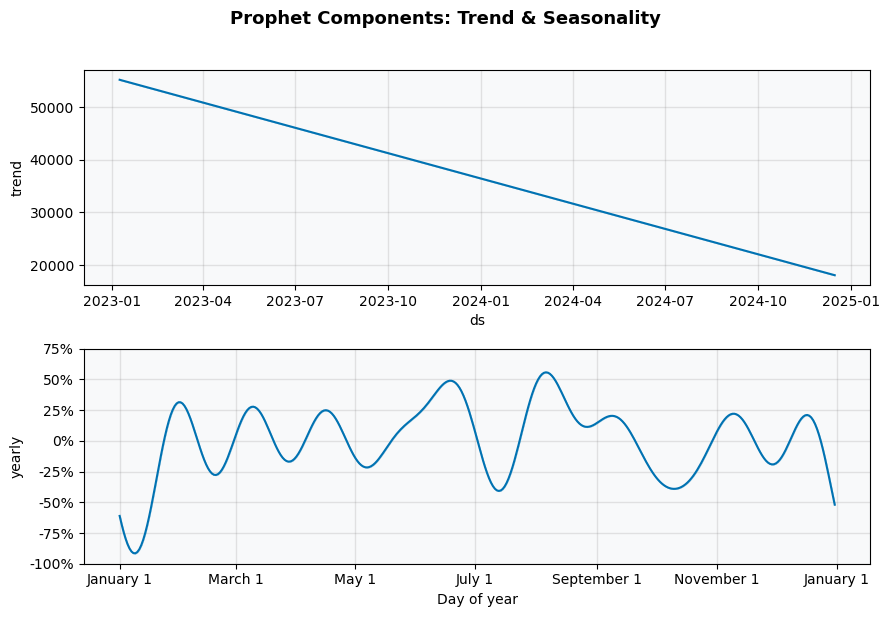

 Saved: plots/prophet_forecast.png & plots/prophet_components.png


In [35]:
# -------------------------------------------------------
# Prophet Forecast Plot
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 6))

# Plot training data
ax.plot(prophet_train['ds'], prophet_train['y'],
        color='#1E5F8C', linewidth=2, label='Training Data')

# Plot actual test values
ax.plot(prophet_test['ds'], prophet_test['y'],
        color='#EB5757', linewidth=2.5, label='Actual (Test)', zorder=5)

# Plot Prophet predictions with uncertainty band
ax.plot(prophet_test_pred['ds'], prophet_test_pred['yhat'],
        color='#F5A623', linewidth=2.5, linestyle='--', label='Prophet Forecast')
ax.fill_between(prophet_test_pred['ds'],
                prophet_test_pred['yhat_lower'],
                prophet_test_pred['yhat_upper'],
                alpha=0.25, color='#F5A623', label='80% Confidence Interval')

# Cutoff line
ax.axvline(test_ts['week'].iloc[0], color='black', linestyle=':', linewidth=2, label='Train/Test Cutoff')

ax.set_title('Prophet Forecast vs Actual Demand', fontsize=14, fontweight='bold')
ax.set_ylabel('Weekly Equipment Demand', fontsize=12)
ax.set_xlabel('Week', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plots/prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# Prophet components plot (shows trend, seasonality separately)
fig2 = prophet_model.plot_components(prophet_forecast)
fig2.suptitle('Prophet Components: Trend & Seasonality', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: plots/prophet_forecast.png & plots/prophet_components.png')

In [36]:
def create_lag_features(df_ts, target_col='total_qty'):

    df_feat = df_ts.copy()

    # Ensure datetime
    df_feat['week'] = pd.to_datetime(df_feat['week'])

    # -------------------
    # Lag features
    # -------------------
    lags = [1,2,3,4,8,13,26,52]

    for lag in lags:
        df_feat[f'lag_{lag}'] = df_feat[target_col].shift(lag)

    # -------------------
    # Rolling statistics
    # -------------------
    df_feat['rolling_mean_4'] = (
        df_feat[target_col]
        .shift(1)
        .rolling(4)
        .mean()
    )

    df_feat['rolling_mean_13'] = (
        df_feat[target_col]
        .shift(1)
        .rolling(13)
        .mean()
    )

    df_feat['rolling_std_4'] = (
        df_feat[target_col]
        .shift(1)
        .rolling(4)
        .std()
    )

    df_feat['rolling_min_4'] = (
        df_feat[target_col]
        .shift(1)
        .rolling(4)
        .min()
    )

    df_feat['rolling_max_4'] = (
        df_feat[target_col]
        .shift(1)
        .rolling(4)
        .max()
    )

    # -------------------
    # Difference features
    # -------------------
    df_feat['diff_1'] = df_feat[target_col].diff(1)
    df_feat['diff_4'] = df_feat[target_col].diff(4)
    df_feat['diff_52'] = df_feat[target_col].diff(52)

    # -------------------
    # Calendar Features
    # -------------------
    df_feat['month'] = df_feat['week'].dt.month
    df_feat['quarter'] = df_feat['week'].dt.quarter

    df_feat['week_of_year'] = (
        df_feat['week']
        .dt.isocalendar()
        .week
        .astype(int)
    )

    df_feat['year'] = df_feat['week'].dt.year

    df_feat['is_q_end'] = (
        df_feat['week']
        .dt.is_quarter_end
        .astype(int)
    )

    # -------------------
    # Cyclical encoding
    # -------------------
    df_feat['month_sin'] = np.sin(2*np.pi*df_feat['month']/12)
    df_feat['month_cos'] = np.cos(2*np.pi*df_feat['month']/12)

    df_feat['week_sin'] = np.sin(
        2*np.pi*df_feat['week_of_year']/52
    )

    df_feat['week_cos'] = np.cos(
        2*np.pi*df_feat['week_of_year']/52
    )

    return df_feat

In [37]:
print("Rows in ts:", len(ts))
print(ts.head())
print(ts.tail())

Rows in ts: 101
        week  total_qty
0 2023-01-09      31.00
1 2023-01-16      49.00
2 2023-01-23      28.00
3 2023-01-30 223,054.00
4 2023-02-06      67.00
          week  total_qty
96  2024-11-25 222,200.00
97  2024-12-02      24.00
98  2024-12-09      27.00
99  2024-12-16      49.00
100 2024-12-30 208,849.00


In [38]:
ts_features = create_lag_features(ts)

print(ts_features.isna().sum().sort_values(ascending=False))

diff_52            52
lag_52             52
lag_26             26
rolling_mean_13    13
lag_13             13
lag_8               8
rolling_min_4       4
diff_4              4
rolling_max_4       4
rolling_std_4       4
rolling_mean_4      4
lag_4               4
lag_3               3
lag_2               2
diff_1              1
lag_1               1
year                0
week_sin            0
month_cos           0
month_sin           0
is_q_end            0
week                0
week_of_year        0
quarter             0
month               0
total_qty           0
week_cos            0
dtype: int64


In [39]:
# Remove rows created due to lag/rolling calculations
ts_features = ts_features.dropna().reset_index(drop=True)

# Feature columns for XGBoost
FEATURE_COLS = [
    'lag_1',
    'lag_2',
    'lag_3',
    'lag_4',
    'lag_8',
    'lag_13',
    'lag_26',

    'rolling_mean_4',
    'rolling_mean_13',
    'rolling_std_4',
    'rolling_min_4',
    'rolling_max_4',

    'diff_1',
    'diff_4',
    'diff_52',

    'month',
    'quarter',
    'week_of_year',
    'year',
    'is_q_end',

    'month_sin',
    'month_cos',
    'week_sin',
    'week_cos'
]

print(f"\nFeature engineered dataset shape: {ts_features.shape}")
print(f"Number of features: {len(FEATURE_COLS)}")


Feature engineered dataset shape: (49, 27)
Number of features: 24


In [40]:
print(ts.dtypes)
print(ts['week'].head())
print(ts['week'].tail())

week         datetime64[ns]
total_qty           float64
dtype: object
0   2023-01-09
1   2023-01-16
2   2023-01-23
3   2023-01-30
4   2023-02-06
Name: week, dtype: datetime64[ns]
96    2024-11-25
97    2024-12-02
98    2024-12-09
99    2024-12-16
100   2024-12-30
Name: week, dtype: datetime64[ns]


In [41]:
print(ts.shape)

print(ts.dtypes)

print(ts.head())

print(ts.tail())
print(ts['week'].isna().sum())
print(ts['week'].dtype)

(101, 2)
week         datetime64[ns]
total_qty           float64
dtype: object
        week  total_qty
0 2023-01-09      31.00
1 2023-01-16      49.00
2 2023-01-23      28.00
3 2023-01-30 223,054.00
4 2023-02-06      67.00
          week  total_qty
96  2024-11-25 222,200.00
97  2024-12-02      24.00
98  2024-12-09      27.00
99  2024-12-16      49.00
100 2024-12-30 208,849.00
0
datetime64[ns]


In [42]:
# ============================================================
# XGBoost Training with TimeSeriesSplit Cross-Validation
# ============================================================
# TimeSeriesSplit respects temporal ordering — each fold uses
# only past data to predict future data.

print('🚀 Training XGBoost model with TimeSeriesSplit CV...')

# Temporal split on the feature-engineered dataset
xgb_split_idx = len(ts_features) - TEST_WEEKS
X_train = ts_features.iloc[:xgb_split_idx][FEATURE_COLS]
y_train = ts_features.iloc[:xgb_split_idx]['total_qty']
X_test  = ts_features.iloc[xgb_split_idx:][FEATURE_COLS]
y_test  = ts_features.iloc[xgb_split_idx:]['total_qty']
test_weeks_xgb = ts_features.iloc[xgb_split_idx:]['week']

print(f'  X_train shape: {X_train.shape}')
print(f'  X_test shape:  {X_test.shape}')

# -------------------------------------------------------
# Hyperparameter Tuning via GridSearchCV
# We search over a small grid — a larger grid would be used
# in production with more compute time.
# -------------------------------------------------------
param_grid = {
    'n_estimators':     [200, 400],
    'max_depth':        [4, 6],
    'learning_rate':    [0.05, 0.1],
    'subsample':        [0.8],
    'colsample_bytree': [0.8],
    'min_child_weight': [3]
}

tscv = TimeSeriesSplit(n_splits=5)

xgb_base = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    tree_method='hist',  # Faster training
    verbosity=0
)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

xgb_model = grid_search.best_estimator_
print(f'\n✅ Best parameters: {grid_search.best_params_}')
print(f'   Best CV RMSE: {-grid_search.best_score_:.1f}')

🚀 Training XGBoost model with TimeSeriesSplit CV...
  X_train shape: (36, 24)
  X_test shape:  (13, 24)
Fitting 5 folds for each of 8 candidates, totalling 40 fits

✅ Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 400, 'subsample': 0.8}
   Best CV RMSE: 26384.9


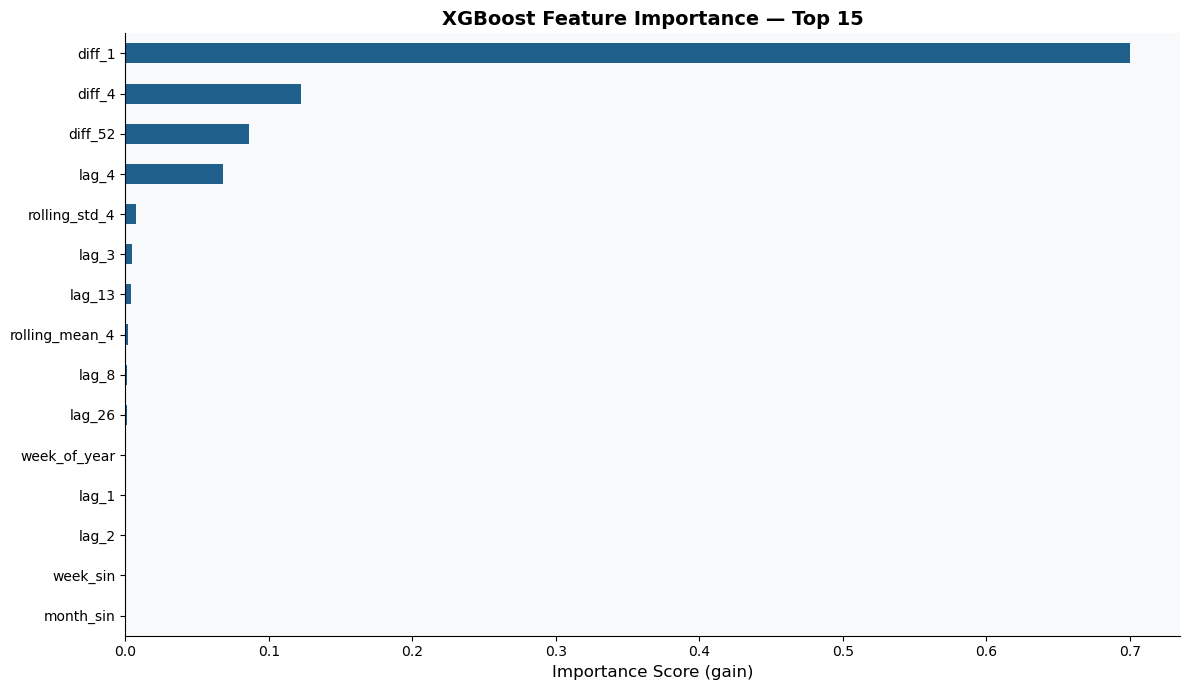

📊 Saved: plots/xgb_feature_importance.png

🔍 KEY INSIGHT: High-importance lag features confirm that recent demand
   is the strongest predictor of future demand — a classic autocorrelation pattern.


In [43]:
# XGBoost predictions on test set
xgb_predictions = xgb_model.predict(X_test).clip(min=0)

# Feature Importance Plot
fig, ax = plt.subplots(figsize=(12, 7))
feat_imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)
feat_imp.nlargest(15).sort_values().plot(kind='barh', color='#1E5F8C', ax=ax)
ax.set_title('XGBoost Feature Importance — Top 15', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score (gain)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plots/xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('📊 Saved: plots/xgb_feature_importance.png')
print('\n🔍 KEY INSIGHT: High-importance lag features confirm that recent demand')
print('   is the strongest predictor of future demand — a classic autocorrelation pattern.')

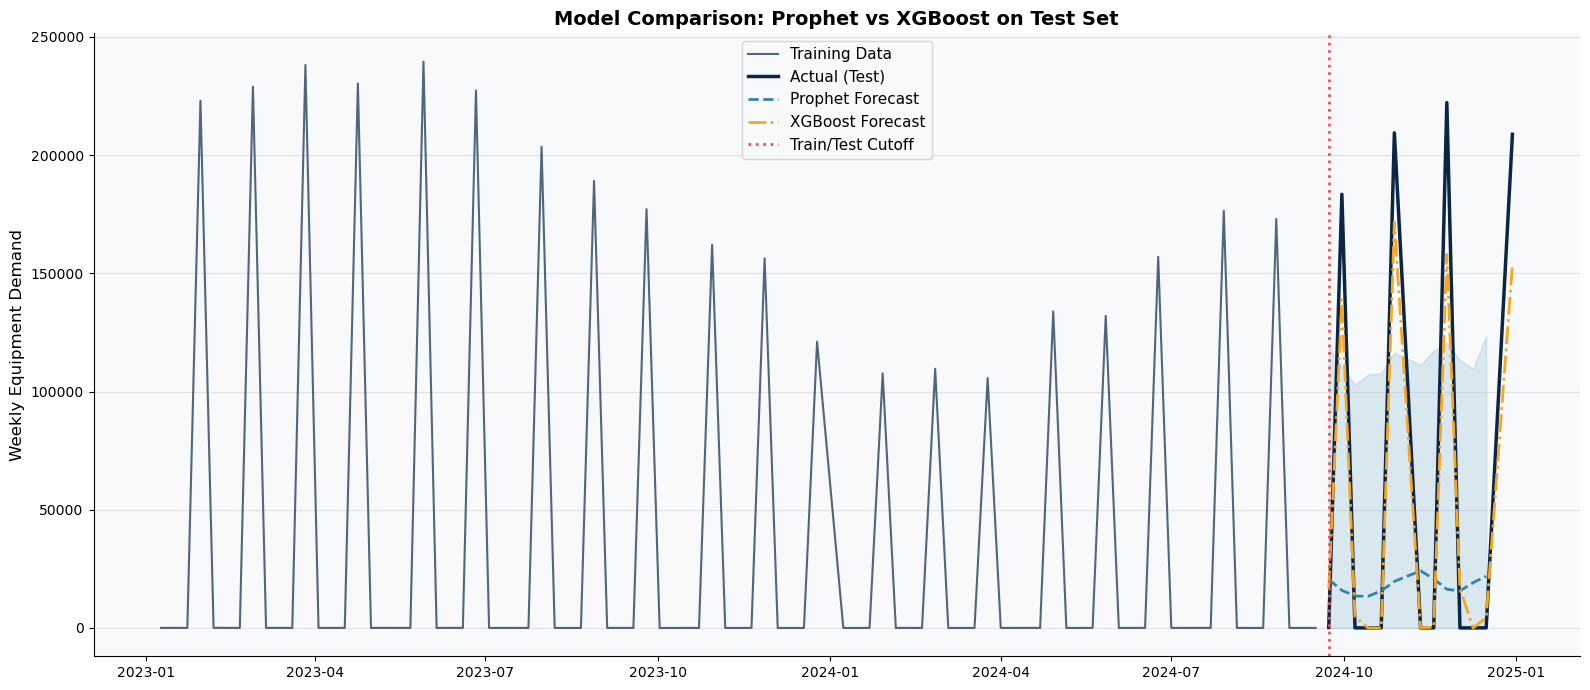

📊 Saved: plots/model_comparison.png


In [44]:
# -------------------------------------------------------
# XGBoost vs Prophet — Combined Forecast Comparison Plot
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 7))

# Training data
ax.plot(train_ts['week'], train_ts['total_qty'],
        color='#0A2647', linewidth=1.5, alpha=0.7, label='Training Data')

# Actual test values
ax.plot(test_ts['week'], test_ts['total_qty'],
        color='#0A2647', linewidth=2.5, label='Actual (Test)')

# Prophet predictions
ax.plot(prophet_test_pred['ds'], prophet_test_pred['yhat'],
        color='#2E86AB', linewidth=2, linestyle='--', label='Prophet Forecast')
ax.fill_between(prophet_test_pred['ds'],
                prophet_test_pred['yhat_lower'],
                prophet_test_pred['yhat_upper'],
                alpha=0.15, color='#2E86AB')

# XGBoost predictions
ax.plot(test_weeks_xgb, xgb_predictions,
        color='#F5A623', linewidth=2, linestyle='-.', label='XGBoost Forecast')

ax.axvline(test_ts['week'].iloc[0], color='#EB5757', linestyle=':', linewidth=2, label='Train/Test Cutoff')
ax.set_title('Model Comparison: Prophet vs XGBoost on Test Set', fontsize=14, fontweight='bold')
ax.set_ylabel('Weekly Equipment Demand', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: plots/model_comparison.png')

In [45]:
# ============================================================
# PART D: Evaluation — MAE, RMSE & MAPE
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

HORIZONS = {
    '30-day (4 wks)': 4,
    '60-day (8 wks)': 8,
    '90-day (13 wks)': 13
}

results = []

print("Actual observations :", len(test_ts))
print("Prophet predictions :", len(prophet_test_pred))
print("XGBoost predictions :", len(xgb_predictions))

for horizon_name, weeks in HORIZONS.items():

    # -------------------------
    # Actual values
    # -------------------------
    actual = test_ts['total_qty'].to_numpy()

    # -------------------------
    # Prophet predictions
    # -------------------------
    prophet_pred = prophet_test_pred['yhat'].to_numpy()

    # -------------------------
    # XGBoost predictions
    # -------------------------
    xgb_pred = np.asarray(xgb_predictions)

    # Evaluate each model
    for model_name, pred in [
        ("Prophet", prophet_pred),
        ("XGBoost", xgb_pred)
    ]:

        # Make lengths consistent
        n = min(weeks, len(actual), len(pred))

        actual_h = actual[:n]
        pred_h = pred[:n]

        mae = mean_absolute_error(actual_h, pred_h)
        rmse = np.sqrt(mean_squared_error(actual_h, pred_h))
        mape = np.mean(
            np.abs((actual_h - pred_h) / (actual_h + 1e-9))
        ) * 100

        results.append({
            "Horizon": horizon_name,
            "Model": model_name,
            "MAE": round(mae, 2),
            "RMSE": round(rmse, 2),
            "MAPE (%)": round(mape, 2)
        })

results_df = pd.DataFrame(results)

print("\n========== Evaluation Results ==========\n")

display(results_df)

print("\n========== Pivot Table ==========\n")

display(
    results_df.pivot(
        index="Horizon",
        columns="Model",
        values=["MAE", "RMSE", "MAPE (%)"]
    )
)

Actual observations : 13
Prophet predictions : 12
XGBoost predictions : 13

========== Evaluation Results ==========



,Horizon,Model,MAE,RMSE,MAPE (%)
0,30-day (4 wks),Prophet,"53,659.34","84,895.89","23,634.42"
1,30-day (4 wks),XGBoost,"16,453.42","23,891.59","4,832.53"
2,60-day (8 wks),Prophet,"58,103.38","90,887.78","32,163.14"
3,60-day (8 wks),XGBoost,"12,982.17","21,504.82","2,574.71"
4,90-day (13 wks),Prophet,"60,603.19","95,540.69","36,493.17"
5,90-day (13 wks),XGBoost,"18,777.21","29,278.87","7,646.47"



========== Pivot Table ==========



MAE                RMSE            MAPE (%)         
Model             Prophet   XGBoost   Prophet   XGBoost   Prophet  XGBoost
Horizon                                                                   
30-day (4 wks)  53,659.34 16,453.42 84,895.89 23,891.59 23,634.42 4,832.53
60-day (8 wks)  58,103.38 12,982.17 90,887.78 21,504.82 32,163.14 2,574.71
90-day (13 wks) 60,603.19 18,777.21 95,540.69 29,278.87 36,493.17 7,646.47

In [46]:
# ============================================================
# EXPORT: Generate forecast_results.json for the Dashboard
# ============================================================
# This script generates the JSON file that powers the
# Next.js dashboard. Crucially:
#   - It contains ONLY aggregated numbers, not raw records
#   - The raw CSV data is never exposed to the frontend

# Generate 90-day (13 week) future forecast using XGBoost
# We use a recursive strategy: predict one week at a time,
# feeding the prediction back as a lag feature.

FORECAST_WEEKS = 13
forecast_reference = pd.Timestamp.now()

# Build future feature rows recursively
ts_extended = ts.copy()
future_preds = []

for i in range(FORECAST_WEEKS):
    future_week = forecast_reference + pd.Timedelta(weeks=i+1)
    ts_extended_feat = create_lag_features(ts_extended)
    ts_extended_feat = ts_extended_feat.dropna()
    
    # Use the last row's features to predict next week
    last_row = ts_extended_feat.tail(1)[FEATURE_COLS]
    pred = float(xgb_model.predict(last_row).clip(min=0)[0])
    
    # Append prediction to the series (for next lag calculation)
    new_row = pd.DataFrame({'week': [future_week], 'total_qty': [pred]})
    ts_extended = pd.concat([ts_extended, new_row], ignore_index=True)
    future_preds.append({'week': future_week.strftime('%Y-%m-%d'), 'forecast': round(pred)})

print(' 90-day recursive XGBoost forecast generated:')
for fp in future_preds:
    print(f"   {fp['week']}: {fp['forecast']:,} units")

 90-day recursive XGBoost forecast generated:
   2026-07-14: 153,854 units
   2026-07-21: 39,273 units
   2026-07-28: 19,300 units
   2026-08-04: 14,769 units
   2026-08-11: 8,979 units
   2026-08-18: 11,509 units
   2026-08-25: 11,614 units
   2026-09-01: 6,364 units
   2026-09-08: 4,669 units
   2026-09-15: 9,609 units
   2026-09-22: 6,152 units
   2026-09-29: 5,237 units
   2026-10-06: 5,831 units


In [47]:
# ============================================================
# Build and Save the Complete Dashboard JSON
# ============================================================

# Historical monthly demand (for the timeline chart)
monthly_hist = (
    df.groupby(df['TRX_DATE'].dt.to_period('M'))['QUANTITY']
    .sum()
    .reset_index()
)
monthly_hist.columns = ['month', 'total_qty']
monthly_hist['month'] = monthly_hist['month'].astype(str)

# Market breakdown
market_data = (
    df.groupby('OM_MARKET_TYPE')['QUANTITY']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
total_qty = market_data['QUANTITY'].sum()
market_data['pct'] = (market_data['QUANTITY'] / total_qty * 100).round(1)

# Category breakdown
cat_data = (
    df.groupby('EQUIPMENT_CATEGORY')['QUANTITY']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
cat_data['pct'] = (cat_data['QUANTITY'] / total_qty * 100).round(1)

# Compile metrics
eval_metrics = {}
for r in results:
    key = r['Horizon'].replace(' ', '_')
    if key not in eval_metrics:
        eval_metrics[key] = {}
    eval_metrics[key][r['Model'].lower() + '_mae'] = r['MAE']
    eval_metrics[key][r['Model'].lower() + '_rmse'] = r['RMSE']

# Final output JSON
dashboard_json = {
    'generated_at': datetime.now().strftime('%Y-%m-%d'),
    'model_used': 'XGBoost',
    'total_records': int(len(df)),
    'forecast_reference_date': forecast_reference.strftime('%Y-%m-%d'),
    'model_metrics': eval_metrics,
    'kpi_summary': {
        'total_orders': int(len(df)),
        'unique_equipment_types': int(df['DESCRIPTION'].nunique()),
        'avg_hire_duration_days': int(df['HIRE_DURATION'].median()),
        'total_qty_forecast_30d': int(sum(fp['forecast'] for fp in future_preds[:4])),
        'total_qty_forecast_60d': int(sum(fp['forecast'] for fp in future_preds[:8])),
        'total_qty_forecast_90d': int(sum(fp['forecast'] for fp in future_preds)),
        'most_demanded_category': cat_data.iloc[0]['EQUIPMENT_CATEGORY']
    },
    'weekly_demand_forecast': future_preds,
    'monthly_demand_history': monthly_hist.to_dict(orient='records'),
    'market_breakdown': market_data.rename(columns={'OM_MARKET_TYPE': 'market', 'QUANTITY': 'total_qty'}).to_dict(orient='records'),
    'category_volume': cat_data.rename(columns={'EQUIPMENT_CATEGORY': 'category', 'QUANTITY': 'total_qty'}).to_dict(orient='records')
}

# Save to dashboard
os.makedirs('hire-dashboard/public/data', exist_ok=True)
json_path = 'hire-dashboard/public/data/forecast_results.json'
with open(json_path, 'w') as f:
    json.dump(dashboard_json, f, indent=2, default=str)

print(f'✅ Dashboard JSON saved: {json_path}')
print(f'   File size: {os.path.getsize(json_path) / 1024:.1f} KB')

✅ Dashboard JSON saved: hire-dashboard/public/data/forecast_results.json
   File size: 7.0 KB


--- Analyzing Equipment Permanently Leaving the Fleet ---
Found 7233 records of equipment being sold or adjusted out of inventory.

--- Top 5 Categories Losing the Most Inventory ---


,OM_SERVICE_TYPE,QUANTITY
0,03 Concrete Construction,"236,799.00"
1,21 Heat Tracing,"1,329.00"
2,01 Commercial Scaffolding,248.00
3,32 ISS Specialty Services,38.00
4,00 NoServiceType,"-5,287.00"


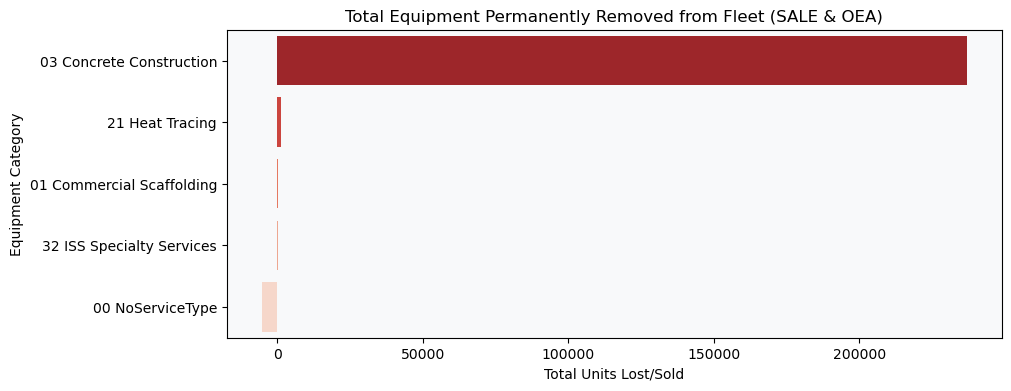

💡 BUSINESS RECOMMENDATION FOR PROCUREMENT:
The procurement team should cross-reference this chart with our HIRE forecast.
If a category is at the top of this 'Lost Inventory' list BUT also has high predicted rental demand next month, we are at extreme risk of a stockout and must purchase replacement units immediately!


In [48]:
# %% [markdown]
# ### 13. Bonus Business Insight: Inventory Depletion (SALE & OEA)
# Even though our machine learning model only forecasts 'HIRE' demand, it is incredibly important to track `SALE` and `OEA` (internal adjustments/scrap) orders. 
# 
# **Why?** Because these orders represent equipment that is *permanently leaving our inventory*. By analyzing this, we can tell the procurement team exactly how much new equipment they need to buy to replace what was lost!

# %%
print("--- Analyzing Equipment Permanently Leaving the Fleet ---")

# 1. Reload the raw dataset just for this analysis (so we don't mess up our ML data)
raw_df = pd.read_csv('BrandDummy_Data.csv')

# 2. Filter for orders where equipment is leaving (SALE or OEA)
if 'ORDER_TYPE' in raw_df.columns:
    depletion_df = raw_df[raw_df['ORDER_TYPE'].isin(['SALE', 'OEA'])].copy()
    print(f"Found {len(depletion_df)} records of equipment being sold or adjusted out of inventory.")
    
    # 3. Clean up the quantity and categories
    if 'QUANTITY' in depletion_df.columns and 'OM_SERVICE_TYPE' in depletion_df.columns:
        # Group by category to see what we are losing the most of
        lost_inventory = depletion_df.groupby('OM_SERVICE_TYPE')['QUANTITY'].sum().sort_values(ascending=False).reset_index()
        
        print("\n--- Top 5 Categories Losing the Most Inventory ---")
        display(lost_inventory.head(5))
        
        # 4. Visualize the Inventory Depletion
        plt.figure(figsize=(10, 4))
        sns.barplot(data=lost_inventory.head(10), x='QUANTITY', y='OM_SERVICE_TYPE', palette='Reds_r')
        plt.title("Total Equipment Permanently Removed from Fleet (SALE & OEA)")
        plt.xlabel("Total Units Lost/Sold")
        plt.ylabel("Equipment Category")
        plt.show()
        
        # 5. Final Business Recommendation
        print("💡 BUSINESS RECOMMENDATION FOR PROCUREMENT:")
        print("The procurement team should cross-reference this chart with our HIRE forecast.")
        print("If a category is at the top of this 'Lost Inventory' list BUT also has high predicted rental demand next month, we are at extreme risk of a stockout and must purchase replacement units immediately!")
else:
    print("Could not find ORDER_TYPE column to perform this analysis.")